In [1]:
# Suppress warning messages to keep the output clean
import warnings
warnings.filterwarnings("ignore")

# Import essential libraries for data handling and analysis
import numpy as np                  # For numerical operations
import pandas as pd                # For working with dataframes and data manipulation
#import yfinance as yf              # For downloading historical market data

# Import technical analysis indicators from the 'ta' library
from ta.momentum import RSIIndicator           # Relative Strength Index for momentum analysis
from ta.trend import MACD                      # Moving Average Convergence Divergence for trend detection
from ta.volatility import BollingerBands       # Bollinger Bands for measuring price volatility
from ta.volatility import AverageTrueRange     # Average True Range for measuring market volatility
from ta.trend import SMAIndicator              # Simple Moving Average for trend smoothing


In [2]:
from twelvedata import TDClient

td = "d6ccf0d1458441bda227ea6a01e2ac08"

In [3]:
def fetch_forex_data(symbol: str, interval: str = "1day", outputsize: int = 5000, apikey: str = td) -> pd.DataFrame:
    try:
        # Initialize client
        td = TDClient(apikey=apikey)

        # Fetch data
        ts = td.time_series(
            symbol=symbol,
            interval=interval,
            outputsize=outputsize,
            timezone="UTC"
        ).as_pandas()

        if ts is None or ts.empty:
            raise ValueError(f"No data returned for symbol: {symbol}")

        # Reset index if needed
        ts = ts.rename_axis("Date").reset_index()

        # Ensure required columns are available
        required_cols = ['Date', 'open', 'high', 'low', 'close']
        missing = [col for col in required_cols if col not in ts.columns]
        if missing:
            raise KeyError(f"Missing expected columns: {missing}")

        # Clean and standardize column names
        df = ts[required_cols].copy()
        df.columns = ['Date', 'Open', 'High', 'Low', 'Close']
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)

        # Add dummy Volume column if needed
        df['Volume'] = 0

        return df

    except Exception as e:
        print(f"❌ Error fetching data for {symbol}: {e}")
        return pd.DataFrame()  # Return empty DataFrame on error

In [4]:
df = fetch_forex_data("CAD/JPY", apikey=td)
if df.empty:
    print("Data fetch failed.")
else:
    print(df.head())


        Date    Open    High     Low   Close  Volume
0 2006-07-14  101.95  103.31  101.89  102.98       0
1 2006-07-17  103.10  103.80  102.86  103.14       0
2 2006-07-18  103.08  103.66  102.74  103.16       0
3 2006-07-19  103.16  103.62  102.78  102.92       0
4 2006-07-20  102.93  103.49  102.77  103.32       0


In [5]:
# Downloading historical daily price data for the EUR/GBP currency pair from Yahoo Finance
#df = yf.download('EURUSD=X', interval='1d', period='30y', progress=False)

# Reset the DataFrame index to convert the 'Date' index into a regular column
#df.reset_index(inplace=True)


In [6]:
# Checking if the downloaded DataFrame is empty (i.e., no data was returned)
if df.empty:
    raise ValueError("No data returned from Yahoo Finance. Try a shorter period or check your internet.")

In [7]:
# PREPRPOCESSING

In [8]:
# Cleaning columns and drop NaNs
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
df.dropna(inplace=True)

In [9]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2006-07-14,101.95,103.31,101.89,102.98,0
1,2006-07-17,103.10,103.80,102.86,103.14,0
2,2006-07-18,103.08,103.66,102.74,103.16,0
3,2006-07-19,103.16,103.62,102.78,102.92,0
4,2006-07-20,102.93,103.49,102.77,103.32,0


In [10]:
# Extract and add new time-based features to the DataFrame
df['dayofweek'] = df['Date'].dt.dayofweek   # Day of the week (0=Monday, 6=Sunday)
df['month'] = df['Date'].dt.month           # Month of the year (1=January, 12=December)

In [11]:
# Creating separate pandas Series for High, Low, and Close prices
# This makes it easier to pass them into technical indicator functions
high_series = pd.Series(df['High'].values.flatten(), index=df.index)
low_series = pd.Series(df['Low'].values.flatten(), index=df.index)
close_series = pd.Series(df['Close'].values.flatten(), index=df.index)

In [12]:
# Calculateing the logarithmic return of the closing price
# This measures the percentage change in price on a logarithmic scale
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

In [13]:
# === Technical Indicators Calculation ===

# Calculate 14-period Relative Strength Index (RSI) for momentum analysis
df['RSI'] = RSIIndicator(close=close_series, window=14).rsi()

# Calculate Moving Average Convergence Divergence (MACD) indicators
macd = MACD(close=close_series)
df['MACD'] = macd.macd()                      # MACD line
df['MACD_signal'] = macd.macd_signal()        # Signal line
df['MACD_diff'] = macd.macd_diff()            # MACD histogram (difference between MACD and Signal line)

# Calculate Bollinger Bands for volatility analysis
bb = BollingerBands(close=close_series)
df['BB_upper'] = bb.bollinger_hband()         # Upper Bollinger Band
df['BB_lower'] = bb.bollinger_lband()         # Lower Bollinger Band
df['BB_width'] = df['BB_upper'] - df['BB_lower']  # Band width as a volatility metric

# Calculate Simple Moving Averages (SMAs) for different periods
df['SMA_10'] = SMAIndicator(close=close_series, window=10).sma_indicator()
df['SMA_20'] = SMAIndicator(close=close_series, window=20).sma_indicator()
df['SMA_50'] = SMAIndicator(close=close_series, window=50).sma_indicator()
df['SMA_100'] = SMAIndicator(close=close_series, window=100).sma_indicator()

# Calculate Average True Range (ATR) to measure market volatility
atr = AverageTrueRange(high=high_series, low=low_series, close=close_series, window=14)
df['ATR'] = atr.average_true_range()


In [14]:
print(type(df['Close']), df['Close'].shape)

<class 'pandas.core.series.Series'> (5000,)


In [15]:
df.tail()

,Date,Open,High,Low,Close,Volume,dayofweek,month,Log_Return,RSI,...,MACD_signal,MACD_diff,BB_upper,BB_lower,BB_width,SMA_10,SMA_20,SMA_50,SMA_100,ATR
4995,2025-07-02,105.106,105.777,105.046,105.669,0,2,7,0.005751,51.260185,...,0.276097,-0.135278,106.643022,105.199078,1.443943,105.7859,105.92105,105.07834,104.36618,0.751481
4996,2025-07-03,105.669,107.026,105.575,106.662,0,3,7,0.009353,60.473717,...,0.261993,-0.056415,106.748108,105.165992,1.582116,105.8162,105.95705,105.14280,104.40240,0.801446
4997,2025-07-04,106.659,106.717,106.087,106.202,0,4,7,-0.004322,55.262205,...,0.253050,-0.035773,106.771187,105.191313,1.579875,105.7955,105.98125,105.18902,104.44442,0.789200
4998,2025-07-05,106.185,106.185,106.185,106.185,0,5,7,-0.000160,55.073312,...,0.246962,-0.024351,106.775977,105.257223,1.518754,105.8592,106.01660,105.21672,104.48097,0.734043
4999,2025-07-07,106.196,106.556,105.936,106.517,0,0,7,0.003122,58.086419,...,0.247717,0.003020,106.828816,105.248784,1.580033,105.9309,106.03880,105.26140,104.51414,0.725897


In [16]:
# Flatten column names in case any are multi-index tuples (e.g., from groupby or merge operations)
# This ensures all column names are simple strings
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

In [17]:
# Checking for missing (NaN) values in each column and display the total count per column
missing = df.isnull().sum()
missing

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
dayofweek       0
month           0
Log_Return      1
RSI            13
MACD           25
MACD_signal    33
MACD_diff      33
BB_upper       19
BB_lower       19
BB_width       19
SMA_10          9
SMA_20         19
SMA_50         49
SMA_100        99
ATR             0
dtype: int64

In [18]:
# Remove rows with incomplete indicator values
df.dropna(inplace=True)

In [19]:
df.head()

,Date,Open,High,Low,Close,Volume,dayofweek,month,Log_Return,RSI,...,MACD_signal,MACD_diff,BB_upper,BB_lower,BB_width,SMA_10,SMA_20,SMA_50,SMA_100,ATR
99,2006-11-30,102.22,102.37,101.09,101.44,0,3,11,-0.008149,32.591110,...,-0.591529,-0.094050,105.083176,101.290824,3.792352,102.349,103.1870,104.2920,104.0174,0.887673
100,2006-12-01,101.46,102.08,100.48,100.82,0,4,12,-0.006131,29.158834,...,-0.627827,-0.145191,105.066921,100.942079,4.124841,102.169,103.0045,104.2232,103.9958,0.938553
101,2006-12-04,100.80,101.36,100.50,101.14,0,0,12,0.003169,33.076306,...,-0.663699,-0.143488,104.887367,100.765633,4.121733,101.991,102.8265,104.1590,103.9758,0.932942
102,2006-12-05,101.04,101.17,100.26,100.59,0,1,12,-0.005453,30.005076,...,-0.704686,-0.163948,104.817309,100.471691,4.345618,101.764,102.6445,104.0672,103.9501,0.931303
103,2006-12-06,100.55,100.86,100.08,100.38,0,2,12,-0.002090,28.901611,...,-0.748474,-0.175155,104.690265,100.204735,4.485530,101.573,102.4475,103.9606,103.9247,0.920496


In [20]:
# EXPLOITATIVE DATA ANALYSIS

In [21]:
df.describe()

,Date,Open,High,Low,Close,Volume,dayofweek,month,Log_Return,RSI,...,MACD_signal,MACD_diff,BB_upper,BB_lower,BB_width,SMA_10,SMA_20,SMA_50,SMA_100,ATR
count,4901,4901.00000,4901.000000,4901.000000,4901.000000,4901.0,4901.000000,4901.000000,4901.000000,4901.000000,...,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000
mean,2016-04-19 02:33:57.624974592,91.70314,92.240395,91.141045,91.719029,0.0,2.029586,6.455213,0.000008,51.223762,...,0.001792,0.000666,93.953225,89.472527,4.480698,91.715614,91.712876,91.709919,91.711510,1.102422
min,2006-11-30 00:00:00,70.83000,71.320000,68.370000,70.830000,0.0,0.000000,1.000000,-0.062368,11.700173,...,-5.155513,-1.504647,74.792773,68.701958,0.528454,71.855000,72.606000,73.733400,75.244400,0.455339
25%,2011-08-11 00:00:00,82.63500,83.090000,82.180000,82.650000,0.0,1.000000,3.000000,-0.003918,43.440003,...,-0.385683,-0.131922,84.502364,80.860468,2.579895,82.671000,82.711500,82.805800,82.854000,0.796478
50%,2016-04-21 00:00:00,88.75000,89.290000,88.220000,88.770000,0.0,2.000000,6.000000,0.000138,51.005398,...,0.058248,0.007921,90.938409,86.511497,3.744972,88.766000,88.601500,88.698000,88.570300,0.990972
75%,2020-12-31 00:00:00,100.94000,101.515000,100.260000,100.990000,0.0,3.000000,9.000000,0.004384,58.966998,...,0.419585,0.150634,103.883737,98.388960,5.680449,100.921000,100.947000,101.558600,101.213070,1.297394
max,2025-07-07 00:00:00,124.58000,125.570000,122.350000,124.430000,0.0,5.000000,12.000000,0.080430,86.451307,...,1.992779,1.273712,126.568846,117.151554,30.978285,121.387000,120.167500,117.138000,114.836600,3.940527
std,NaN,11.13994,11.167068,11.124433,11.149067,0.0,1.438303,3.462788,0.008455,11.762264,...,0.764847,0.244751,11.358797,10.946925,2.863774,11.104756,11.062478,10.943818,10.749443,0.457110


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4901 entries, 99 to 4999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         4901 non-null   datetime64[ns]
 1   Open         4901 non-null   float64       
 2   High         4901 non-null   float64       
 3   Low          4901 non-null   float64       
 4   Close        4901 non-null   float64       
 5   Volume       4901 non-null   int64         
 6   dayofweek    4901 non-null   int32         
 7   month        4901 non-null   int32         
 8   Log_Return   4901 non-null   float64       
 9   RSI          4901 non-null   float64       
 10  MACD         4901 non-null   float64       
 11  MACD_signal  4901 non-null   float64       
 12  MACD_diff    4901 non-null   float64       
 13  BB_upper     4901 non-null   float64       
 14  BB_lower     4901 non-null   float64       
 15  BB_width     4901 non-null   float64       
 16  SMA_10    

In [23]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Defining a function to plot MACD and RSI indicators for the DataFrame
def plot_macd_rsi(df, title="Indicators"):
    # Create a figure with two subplots: one for MACD, one for RSI
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # === MACD Plot ===
    ax1.plot(df['Date'], df['MACD'], label='MACD', color='blue')              # Plot MACD line
    ax1.plot(df['Date'], df['MACD_signal'], label='Signal', color='orange')   # Plot Signal line
    ax1.bar(df['Date'], df['MACD_diff'], label='MACD Diff', color='gray', alpha=0.5)  # Plot MACD histogram
    ax1.set_title(f"{title} - MACD")
    ax1.legend()
    ax1.grid(True)

    # === RSI Plot ===
    ax2.plot(df['Date'], df['RSI'], label='RSI', color='green')               # Plot RSI line
    ax2.axhline(70, color='red', linestyle='--', label='Overbought')          # Overbought threshold
    ax2.axhline(30, color='blue', linestyle='--', label='Oversold')           # Oversold threshold
    ax2.set_title(f"{title} - RSI")
    ax2.set_ylim(0, 100)
    ax2.legend()
    ax2.grid(True)

    # Optimize layout and display the plot
    plt.tight_layout()
    plt.show()

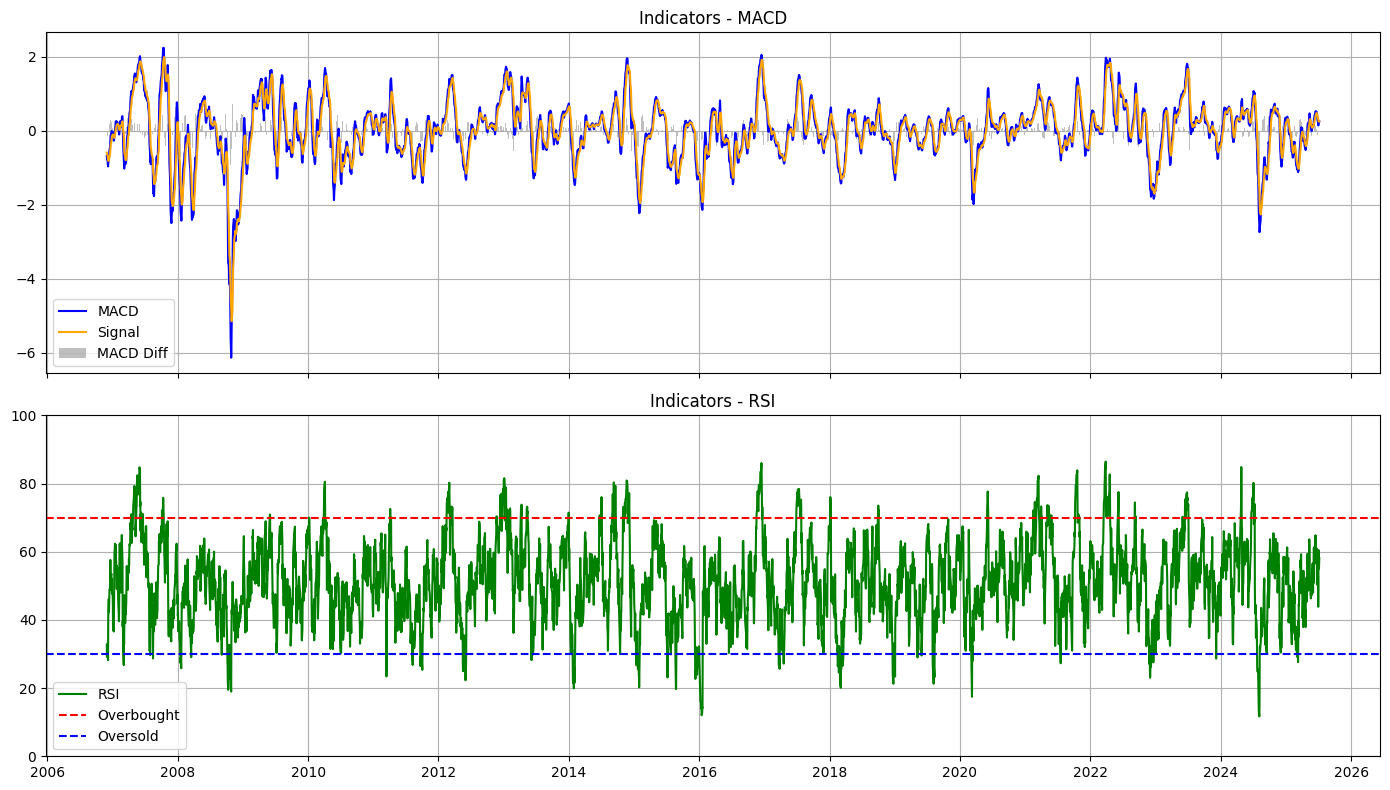

In [24]:
plot_macd_rsi(df)

In [25]:
# Import date formatting tools for better x-axis handling in plots
import matplotlib.dates as mdates

# Define a function to plot Close Price with Bollinger Bands, MACD, and formatted x-axis
def plot_bb_macd_chart(df, title="Technical Analysis"):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])  # Ensure 'Date' is in datetime format for plotting

    # Set up a 3-row subplot layout with custom height ratios
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1.5, 1], hspace=0.3)

    # === 1. Close Price with Bollinger Bands ===
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(df['Date'], df['Close'], label='Close Price', color='black')            # Plot closing price
    ax0.plot(df['Date'], df['BB_upper'], label='BB Upper', color='red', linestyle='--')  # Upper Bollinger Band
    ax0.plot(df['Date'], df['BB_lower'], label='BB Lower', color='blue', linestyle='--') # Lower Bollinger Band
    ax0.fill_between(df['Date'], df['BB_upper'], df['BB_lower'], color='gray', alpha=0.1) # Shaded BB area
    ax0.set_title(f"{title} - Price & Bollinger Bands")
    ax0.legend()
    ax0.grid(True)

    # === 2. MACD Plot ===
    ax1 = fig.add_subplot(gs[1])
    ax1.plot(df['Date'], df['MACD'], label='MACD', color='blue')               # MACD line
    ax1.plot(df['Date'], df['MACD_signal'], label='Signal', color='orange')    # Signal line
    ax1.bar(df['Date'], df['MACD_diff'], label='MACD Diff', color='gray', alpha=0.5)  # MACD histogram
    ax1.set_title("MACD")
    ax1.legend()
    ax1.grid(True)

    # === 3. Shared X-axis Formatting ===
    # Format the x-axis of upper plots with months for better readability
    for ax in [ax0, ax1]:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))                   # Set major ticks every 2 months
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))                   # Format as "Month Year"

    # Optimize layout and display the complete figure
    plt.tight_layout()
    plt.show()

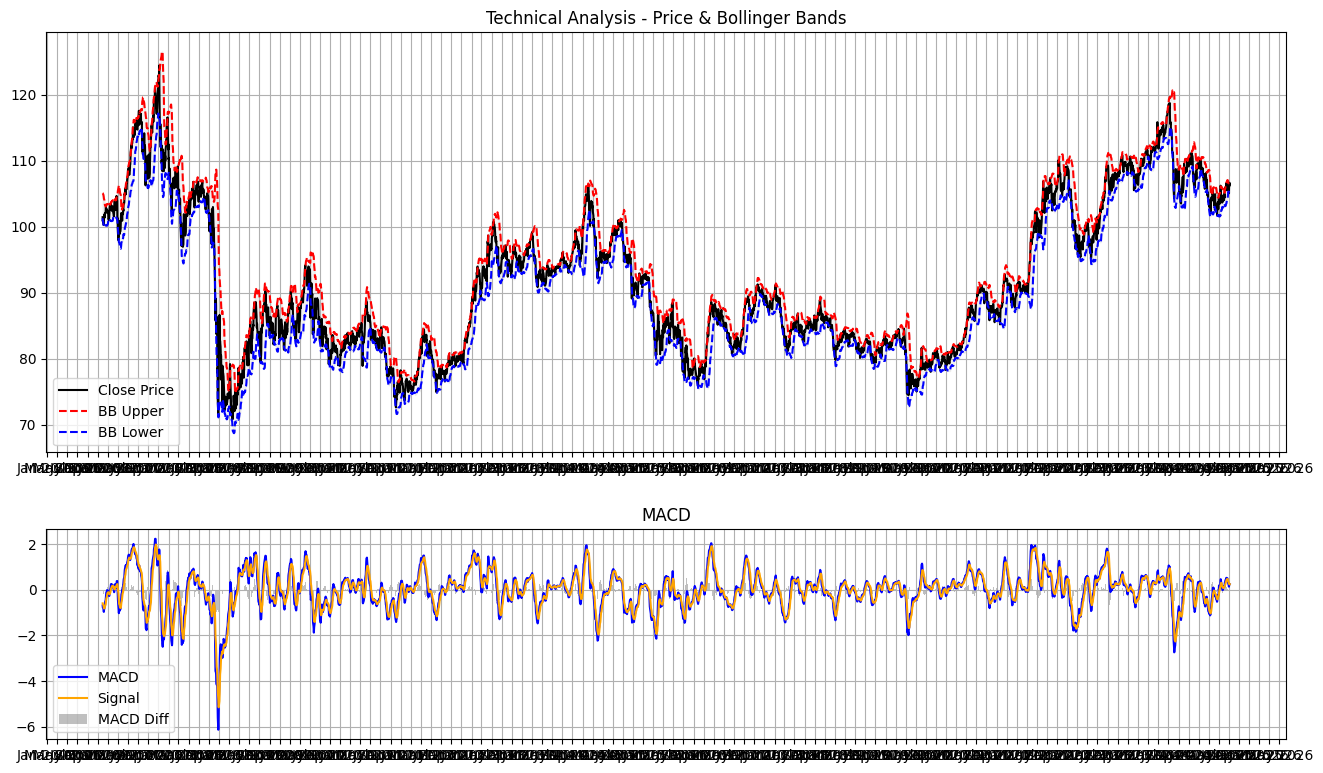

In [26]:
plot_bb_macd_chart(df)

In [27]:
# Display the list of all column names in the DataFrame
df.columns.tolist()

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'dayofweek',
 'month',
 'Log_Return',
 'RSI',
 'MACD',
 'MACD_signal',
 'MACD_diff',
 'BB_upper',
 'BB_lower',
 'BB_width',
 'SMA_10',
 'SMA_20',
 'SMA_50',
 'SMA_100',
 'ATR']

In [28]:
# Create a new DataFrame `comp` by dropping non-essential or categorical columns 
# such as 'dayofweek', 'month', and 'Volume' if they exist
comp = df.drop(columns=["dayofweek", "month", "Volume"], errors='ignore')

In [29]:
# Import seaborn for enhanced visualizations
import seaborn as sns

# Defining a function to plot a heatmap of correlations between numerical features
def plot_correlation_heatmap(comp):
    plt.figure(figsize=(10, 6))  # Set the figure size
    sns.heatmap(
        comp.corr(numeric_only=True),  # Compute correlation matrix of numeric columns
        annot=True,                    # Display correlation values in the heatmap
        cmap='coolwarm',               # Use a diverging colormap for clarity
        center=0                       # Center the colormap at 0 for balanced visual
    )
    plt.title("Correlation Heatmap of Technical Indicators")
    plt.show()

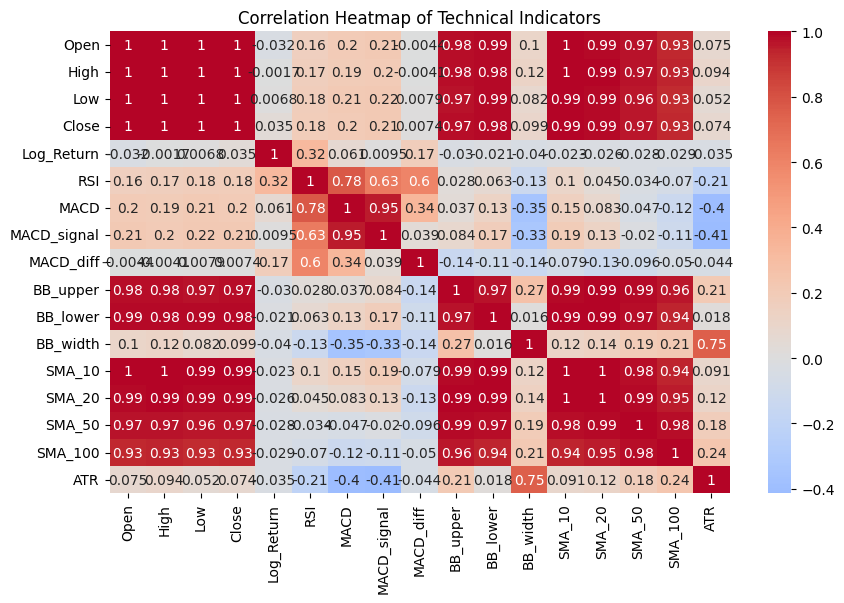

In [30]:
# Call the function to display the correlation heatmap for the technical indicators in 'comp'
plot_correlation_heatmap(comp)

In [31]:
# Define a function to visualize the price trend along with SMAs and Bollinger Bands
def plot_price_trend(df, title="Price & Trend"):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])  # Ensure 'Date' is in datetime format

    # === Plot Price and Trend Indicators ===
    plt.figure(figsize=(16, 8))
    plt.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=1.5)        # Closing price
    plt.plot(df['Date'], df['SMA_20'], label='SMA 20', color='blue', linestyle='--')            # 20-day SMA
    plt.plot(df['Date'], df['SMA_50'], label='SMA 50', color='green', linestyle='--')           # 50-day SMA
    plt.plot(df['Date'], df['SMA_100'], label='SMA 100', color='yellow', linestyle='--')        # 100-day SMA
    plt.plot(df['Date'], df['BB_upper'], label='BB Upper', color='red', linestyle=':')          # Upper Bollinger Band
    plt.plot(df['Date'], df['BB_lower'], label='BB Lower', color='purple', linestyle=':')       # Lower Bollinger Band
    plt.fill_between(df['Date'], df['BB_upper'], df['BB_lower'], color='gray', alpha=0.1)       # Shaded BB region

    # === Customize Plot Aesthetics ===
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.grid(True)
    plt.legend()

    # Format x-axis with month-year ticks every 2 months
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

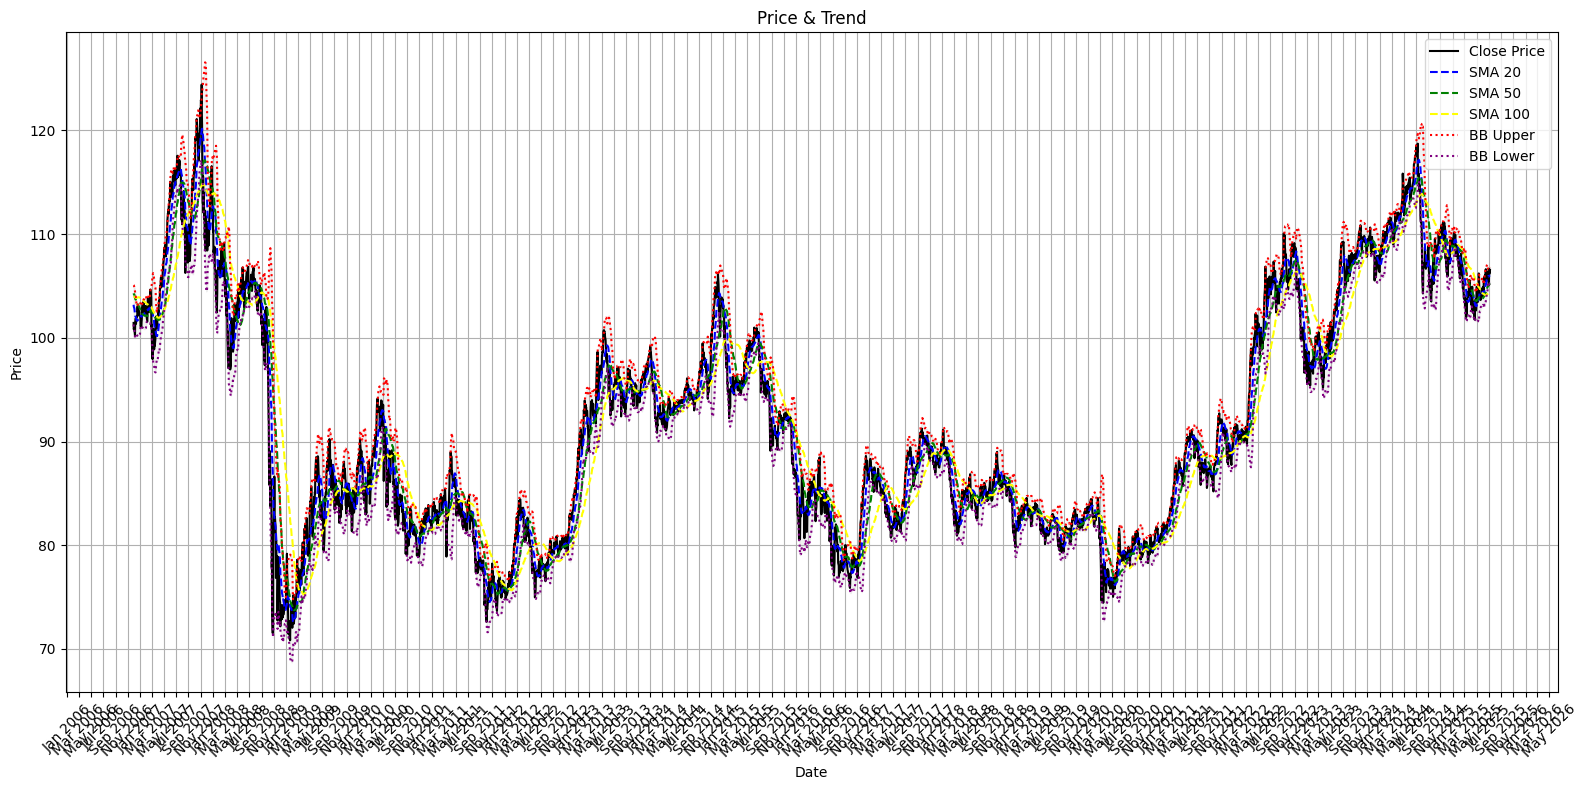

In [32]:
plot_price_trend(df)

In [33]:
# Define a function to plot a scatter matrix (pair plot) for selected technical indicators
def plot_scatter_matrix(df, indicators=None, title="Indicator Pair Plot"):
    # Set default indicators to plot if none are specified
    if indicators is None:
        indicators = ['Close', 'RSI', 'MACD', 'MACD_signal', 'BB_width']

    # Select specified columns and drop rows with missing values
    data = df[indicators].dropna()

    # Plot pairwise relationships with KDE on diagonals and scatter plots on lower triangle
    sns.set(style="ticks", color_codes=True)
    sns.pairplot(data, diag_kind="kde", corner=True)
    plt.suptitle(title, y=1.02)  # Set the main title above the plot
    plt.show()

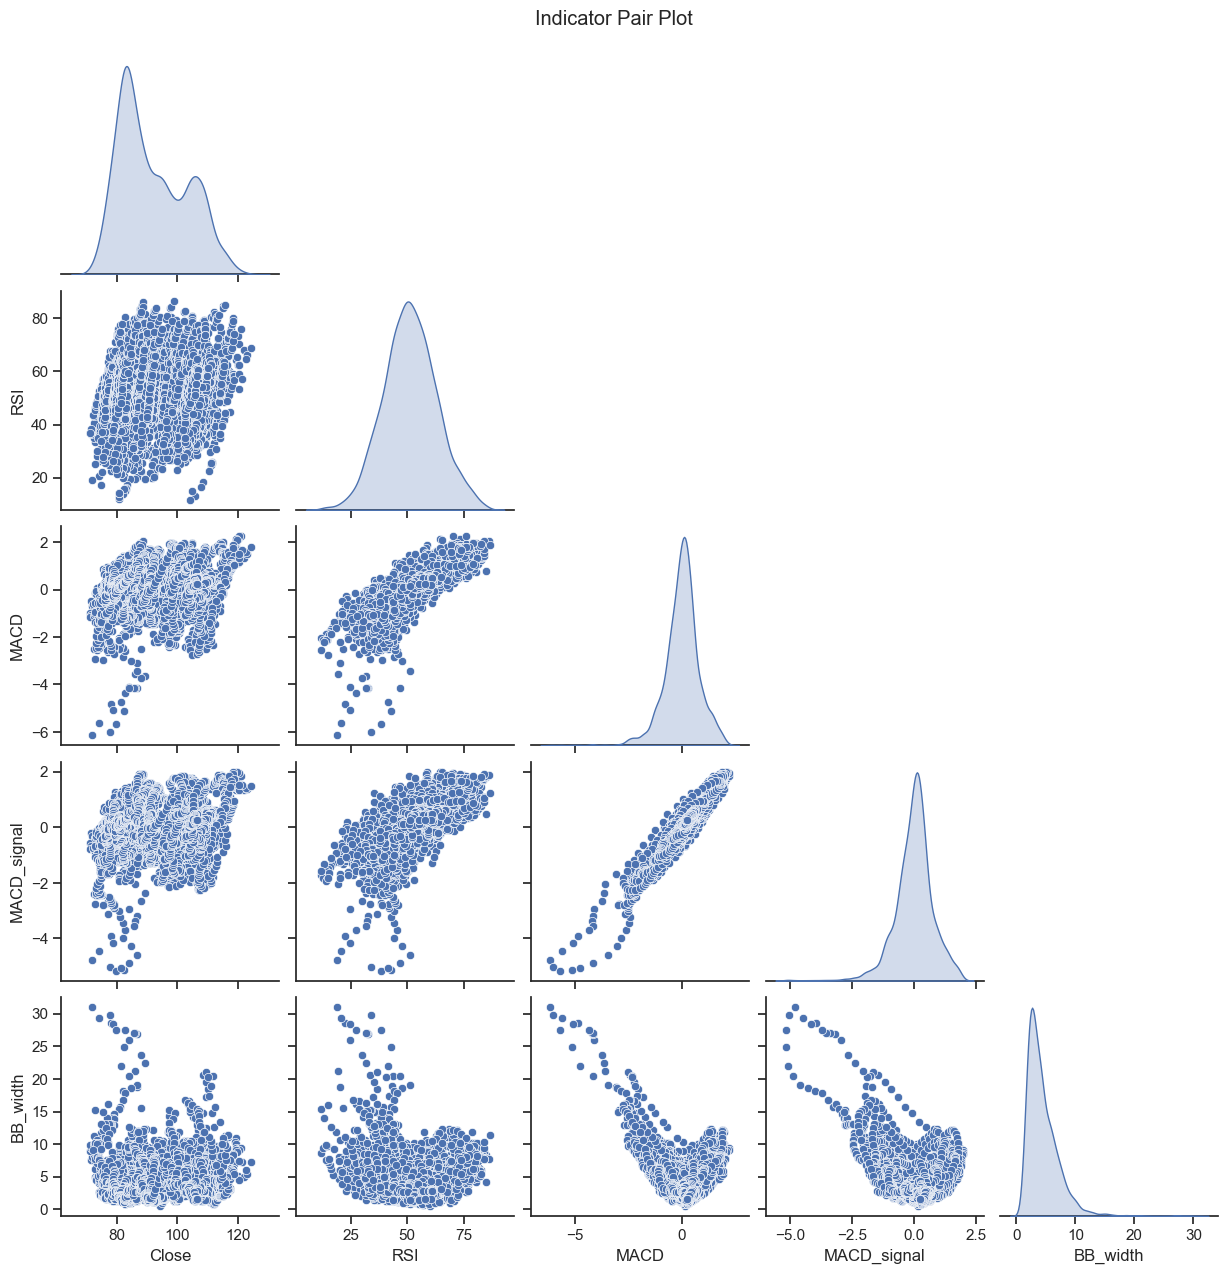

In [34]:
plot_scatter_matrix(df)

In [35]:
# FEATURE ENGINEERING

In [36]:
# === Lag Features ===
# Create lagged versions of the 'Close' price to capture historical price behavior as features
df['lag_1'] = df['Close'].shift(1)  # Close price from 1 day ago
df['lag_2'] = df['Close'].shift(2)  # Close price from 2 days ago
df['lag_3'] = df['Close'].shift(3)  # Close price from 3 days ago

In [37]:
# === Return Features ===
# Calculate the 1-day percentage return of the closing price
df['return_1d'] = ((df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)) * 100

In [38]:
# === Rolling Statistics ===
# Compute rolling statistics to capture short- and medium-term trends and volatility

df['sma_5'] = df['Close'].rolling(5).mean()        # 5-day simple moving average
df['sma_10'] = df['Close'].rolling(10).mean()      # 10-day simple moving average
df['sma_21'] = df['Close'].rolling(21).mean()      # 21-day simple moving average (approx. 1 trading month)

df['volatility_10'] = df['Close'].rolling(10).std()  # 10-day rolling standard deviation (volatility)
df['volatility_21'] = df['Close'].rolling(21).std()  # 21-day rolling standard deviation (volatility)

In [39]:
# === Price Action Features ===

# Extract series for OHLC prices
high_series = df['High'].squeeze()
low_series = df['Low'].squeeze()
open_series = df['Open'].squeeze()
close_series = df['Close'].squeeze()

# Compute the larger value between Open and Close for each row (top of the real body)
high_body_max = pd.concat([open_series, close_series], axis=1).max(axis=1)

# Compute the smaller value between Open and Close for each row (bottom of the real body)
low_body_min = pd.concat([open_series, close_series], axis=1).min(axis=1)

# Calculate upper shadow: difference between the High and the top of the candle body
df['upper_shadow'] = high_series - high_body_max

# Calculate lower shadow: difference between the bottom of the candle body and the Low
df['lower_shadow'] = low_body_min - low_series

In [40]:
# === Temporal Features ===
# Extract time-based features from the 'Date' column

df['dayofweek'] = df['Date'].dt.dayofweek              # Day of the week (0 = Monday, ..., 6 = Sunday)
df['month'] = df['Date'].dt.month                      # Month of the year (1 = January, ..., 12 = December)

# Flags to identify start and end of the trading week
df['is_week_start'] = (df['dayofweek'] == 0).astype(int)  # 1 if Monday, else 0
df['is_week_end'] = (df['dayofweek'] == 4).astype(int)    # 1 if Friday, else 0

In [41]:
# === Targets ===
# Define target variables for supervised learning tasks

df['target_regression'] = df['Close'].shift(-1)                   # Next day's closing price (for regression)
df['target_classification'] = (df['Close'].shift(-1) > df['Close']).astype(int)  # 1 if price goes up next day, else 0 (for classification)

In [42]:
# Remove any remaining rows with missing values to ensure model compatibility
df.dropna(inplace=True)

# Reset the DataFrame index after dropping rows to maintain a clean, continuous index
df.reset_index(drop=True, inplace=True)

In [43]:
df.head()

,Date,Open,High,Low,Close,Volume,dayofweek,month,Log_Return,RSI,...,sma_10,sma_21,volatility_10,volatility_21,upper_shadow,lower_shadow,is_week_start,is_week_end,target_regression,target_classification
0,2006-12-28,102.22,102.66,102.05,102.53,0,3,12,0.002637,52.053849,...,102.484,101.782381,0.293682,0.816039,0.13,0.17,0,0,102.13,0
1,2006-12-29,102.42,102.75,101.95,102.13,0,4,12,-0.003909,47.693937,...,102.490,101.815238,0.284761,0.815455,0.33,0.18,0,1,102.12,0
2,2007-01-01,102.04,102.12,101.94,102.12,0,0,1,-0.000098,47.586629,...,102.496,101.877143,0.275165,0.784896,0.00,0.10,1,0,102.07,0
3,2007-01-02,102.05,102.22,101.73,102.07,0,1,1,-0.000490,47.017014,...,102.451,101.921429,0.305885,0.767263,0.15,0.32,0,0,101.83,0
4,2007-01-03,102.00,102.33,101.68,101.83,0,2,1,-0.002354,44.277313,...,102.330,101.980476,0.285657,0.704851,0.33,0.15,0,0,101.10,0


In [44]:
# Calculate the absolute size of the candlestick body (difference between Close and Open)
df['body'] = (df['Close'] - df['Open']).abs()

# Display the first 5 values of the 'body' column
df['body'].head()

0    0.31
1    0.29
2    0.08
3    0.02
4    0.17
Name: body, dtype: float64

In [45]:
df['body'].describe()

count    4880.000000
mean        0.531146
std         0.545333
min         0.000000
25%         0.160000
50%         0.370000
75%         0.720000
max         6.090000
Name: body, dtype: float64

In [46]:
# === Candle Attributes ===

# Calculate the full candlestick range (high - low) for each day
df['range'] = df['High'] - df['Low']

# Determine the top and bottom of the candlestick body
high_body_max = df[['Open', 'Close']].max(axis=1)  # Upper edge of the candle body
low_body_min = df[['Open', 'Close']].min(axis=1)   # Lower edge of the candle body

# Calculate the size of the upper shadow (wick above the body)
df['upper_shadow'] = df['High'].astype(float) - high_body_max.astype(float)

# Calculate the size of the lower shadow (wick below the body)
df['lower_shadow'] = low_body_min - df['Low']

In [47]:
# === Candlestick Flags ===
# Identify specific candlestick patterns based on body and shadow proportions

# Doji: very small body relative to total range (indecision in the market)
df['is_doji'] = (df['body'] / df['range'] < 0.1).astype(int)

# Hammer: small body with long lower shadow and tiny upper shadow (potential bullish reversal)
df['is_hammer'] = ((df['lower_shadow'] > 2 * df['body']) & 
                   (df['upper_shadow'] < 0.1 * df['body'])).astype(int)

# Inverted Hammer: small body with long upper shadow and tiny lower shadow (potential bullish reversal in downtrend)
df['is_inverted_hammer'] = ((df['upper_shadow'] > 2 * df['body']) & 
                            (df['lower_shadow'] < 0.1 * df['body'])).astype(int)

In [48]:
# === Price Momentum Indicators ===
# Measures the absolute price change over 3 and 7 days
df['momentum_3'] = df['Close'] - df['Close'].shift(3)  # Close today minus close 3 days ago
df['momentum_7'] = df['Close'] - df['Close'].shift(7)  # Close today minus close 7 days ago

# === Rate of Change (ROC) ===
# Measures the percentage change in price over 3 and 7 days
df['roc_3'] = df['Close'].pct_change(periods=3)  # % change from 3 days ago
df['roc_7'] = df['Close'].pct_change(periods=7)  # % change from 7 days ago

# === Rolling Volatility ===
# Calculates the rolling standard deviation (volatility) of the closing price
df['vol_5'] = df['Close'].rolling(window=5).std()   # 5-day rolling volatility
df['vol_10'] = df['Close'].rolling(window=10).std() # 10-day rolling volatility

# === Slope of 5-Day Simple Moving Average (SMA) ===
# Computes the difference between consecutive SMA values to approximate its slope (trend direction)
df['sma_5_slope'] = df['sma_5'].diff()

In [49]:
# === Engulfing Patterns ===
# Store previous day's open and close prices to detect bullish and bearish engulfing patterns

df['prev_close'] = df['Close'].shift(1)  # Previous day's closing price
df['prev_open'] = df['Open'].shift(1)    # Previous day's opening price

In [50]:
# Detect classic candlestick engulfing patterns for potential trend reversals

# Bullish Engulfing:
# Previous candle is bearish (close < open), current is bullish (close > open),
# and current body completely engulfs the previous body
df['is_bullish_engulfing'] = (
    (df['prev_close'] > df['prev_open']) &          # Previous candle is bearish
    (df['Close'] > df['Open']) &                    # Current candle is bullish
    (df['Open'] < df['prev_close']) &               # Current open is lower than previous close
    (df['Close'] > df['prev_open'])                 # Current close is higher than previous open
).astype(int)

# Bearish Engulfing:
# Previous candle is bullish, current is bearish, and current body engulfs previous
df['is_bearish_engulfing'] = (
    (df['prev_open'] > df['prev_close']) &          # Previous candle is bullish
    (df['Close'] < df['Open']) &                    # Current candle is bearish
    (df['Open'] > df['prev_close']) &               # Current open is higher than previous close
    (df['Close'] < df['prev_open'])                 # Current close is lower than previous open
).astype(int)

In [51]:
# === Trend Indicators ===
# Create binary features to capture trend direction and momentum

df['price_above_sma20'] = (df['Close'] > df['SMA_20']).astype(int)     # 1 if price is above 20-day SMA else 0
df['price_above_sma50'] = (df['Close'] > df['SMA_50']).astype(int)     # 1 if price is above 50-day SMA else 0
df['sma_crossover'] = (df['SMA_20'] > df['SMA_50']).astype(int)        # 1 if short-term SMA crosses above long-term SMA else 0
df['log_return_positive'] = (df['Log_Return'] > 0).astype(int)         # 1 if log return is positive (price increased) else 0

In [52]:
# Drop temporary columns used for engulfing pattern detection to clean up the DataFrame
df.drop(columns=['prev_open', 'prev_close'], inplace=True)

In [53]:
df.isnull().sum()

Date                     0
Open                     0
High                     0
Low                      0
Close                    0
Volume                   0
dayofweek                0
month                    0
Log_Return               0
RSI                      0
MACD                     0
MACD_signal              0
MACD_diff                0
BB_upper                 0
BB_lower                 0
BB_width                 0
SMA_10                   0
SMA_20                   0
SMA_50                   0
SMA_100                  0
ATR                      0
lag_1                    0
lag_2                    0
lag_3                    0
return_1d                0
sma_5                    0
sma_10                   0
sma_21                   0
volatility_10            0
volatility_21            0
upper_shadow             0
lower_shadow             0
is_week_start            0
is_week_end              0
target_regression        0
target_classification    0
body                     0
r

In [54]:
df.dropna(inplace=True)

In [55]:
from datetime import timedelta

# Get today's date in UTC without timezone information, and normalize it to midnight (00:00:00)
today = pd.Timestamp.utcnow().replace(tzinfo=None).normalize()

# Calculate the date exactly two weeks ago from today
two_weeks_ago = today - timedelta(days=14)

# Ensure the 'Date' column in the DataFrame is timezone-naive (i.e., has no timezone info)
df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)

# Split the dataset into two parts:
# 1. Training data: all rows with dates older than two weeks ago
df_train = df[df['Date'] < two_weeks_ago].reset_index(drop=True)

# 2. Most recent two weeks: data from two weeks ago up to today
df_last_2weeks = df[df['Date'] >= two_weeks_ago].reset_index(drop=True)

In [56]:
df_last_2weeks.shape

(12, 54)

In [57]:
# MODEL TRAINING

In [58]:
# Import train_test_split to divide the dataset into training and testing sets
from sklearn.model_selection import train_test_split

In [59]:
# Define the target variable for regression and select input features
target = 'target_regression'

# Exclude non-feature columns such as Date and target labels from the feature set
features = df_train.drop(columns=['Date', 'target_regression', 'target_classification'])

In [60]:
# Assign features and target to X and y for model training
X = features          # Feature matrix
y = df_train[target]        # Target variable (next day's closing price)

In [61]:
X.columns.tolist()

['Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'dayofweek',
 'month',
 'Log_Return',
 'RSI',
 'MACD',
 'MACD_signal',
 'MACD_diff',
 'BB_upper',
 'BB_lower',
 'BB_width',
 'SMA_10',
 'SMA_20',
 'SMA_50',
 'SMA_100',
 'ATR',
 'lag_1',
 'lag_2',
 'lag_3',
 'return_1d',
 'sma_5',
 'sma_10',
 'sma_21',
 'volatility_10',
 'volatility_21',
 'upper_shadow',
 'lower_shadow',
 'is_week_start',
 'is_week_end',
 'body',
 'range',
 'is_doji',
 'is_hammer',
 'is_inverted_hammer',
 'momentum_3',
 'momentum_7',
 'roc_3',
 'roc_7',
 'vol_5',
 'vol_10',
 'sma_5_slope',
 'is_bullish_engulfing',
 'is_bearish_engulfing',
 'price_above_sma20',
 'price_above_sma50',
 'sma_crossover',
 'log_return_positive']

In [62]:
# === Train-test split ===
# Split the dataset into training and testing sets (80% train, 20% test)
# shuffle=False ensures chronological order is preserved (important for time series)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

In [63]:
# Display the shape of the training feature set (rows, columns)
X_train.shape

(3887, 51)

In [64]:
# Import the Prophet library for time series forecasting
from prophet import Prophet

In [65]:
# Import Augmented Dickey-Fuller test from statsmodels to check for stationarity
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test on the 'Close' price series
adf_test = adfuller(df_train['Close'])

# Organize and display the ADF test results
adf_results = {
    "Test Statistic": adf_test[0],                   # The test statistic value
    "p-value": adf_test[1],                          # p-value to assess stationarity
    "Lags Used": adf_test[2],                        # Number of lags used in the test
    "Number of Observations Used": adf_test[3],      # Number of observations included
    "Critical Values": adf_test[4],                  # Critical values at 1%, 5%, and 10% confidence levels
}

# Print results in a readable format
for key, value in adf_results.items():
    print(f"{key}: {value}")

Test Statistic: -2.0364561639387175
p-value: 0.2708205548542828
Lags Used: 24
Number of Observations Used: 4834
Critical Values: {'1%': -3.4317034910810587, '5%': -2.862138092178874, '10%': -2.5670883659686106}


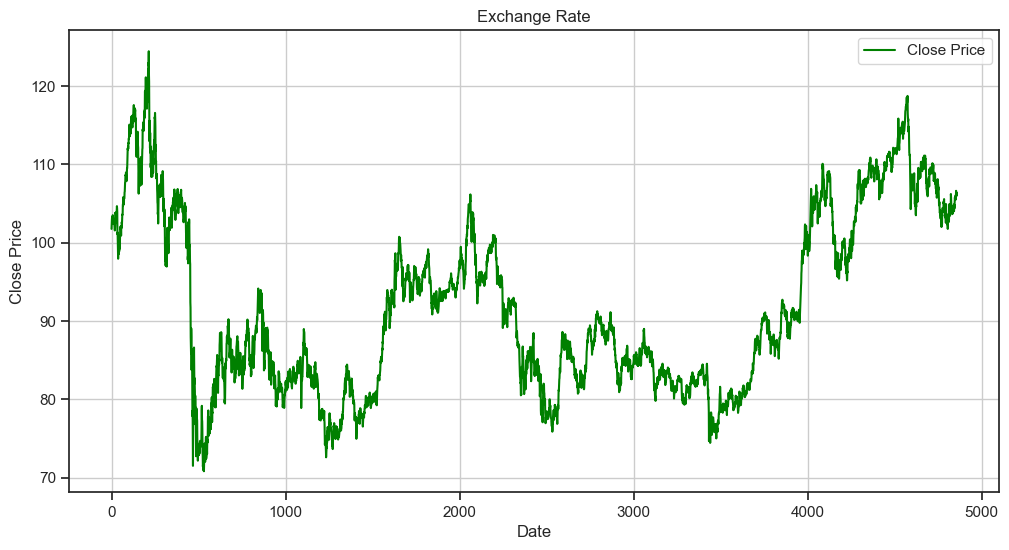

In [66]:
# Plot the differenced 'Close' price to visualize stationarity

plt.figure(figsize=(12, 6))
plt.plot(df_train.index, df_train['Close'], label='Close Price', color='green')  # Plot differenced close prices
plt.title("Exchange Rate")                                       # Chart title
plt.xlabel("Date")                                                       # X-axis label
plt.ylabel("Close Price")                                                # Y-axis label
plt.legend()
plt.grid()
plt.show()

In [67]:
# === Model Evaluation Metrics ===

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define a function to evaluate and print regression performance metrics
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)             # Mean Absolute Error
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))    # Root Mean Squared Error
    r2 = r2_score(y_true, y_pred)                          # R-squared score

    # Display evaluation results
    print(f"{name} Evaluation:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    print()

In [68]:
usable_regressors = [
    'Log_Return', 'RSI', 'MACD', 'upper_shadow',
    'lower_shadow'
]

In [69]:
"""usable_regressors = [
    'Log_Return', 'RSI', 'MACD', 'MACD_signal', 'MACD_diff',
    'BB_width', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_100',
    'ATR', 'return_1d', 'sma_5', 'sma_10', 'sma_21',
    'volatility_10', 'volatility_21', 'upper_shadow',
    'lower_shadow', 'body', 'range'
]"""

"usable_regressors = [\n    'Log_Return', 'RSI', 'MACD', 'MACD_signal', 'MACD_diff',\n    'BB_width', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_100',\n    'ATR', 'return_1d', 'sma_5', 'sma_10', 'sma_21',\n    'volatility_10', 'volatility_21', 'upper_shadow',\n    'lower_shadow', 'body', 'range'\n]"

In [70]:
# Initialize and fit the Prophet model for forecasting

# Prepare the DataFrame in Prophet's expected format:
# 'ds' for datetime column and 'y' for the target variable
# Prepare input for Prophet
# Prepare input DataFrame for Prophet
prophet_df = df_train[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

# Add all available usable regressors
for reg in usable_regressors:
    if reg in df_train.columns:
        prophet_df[reg] = df_train[reg]

# Initialize the Prophet model with daily seasonality enabled
prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.2,      # Higher = more flexible trend shifts
    seasonality_prior_scale=10.0      # Higher = more seasonal variation
)

prophet.add_seasonality(name='monthly', period=30.5, fourier_order=8)

# Register the regressors with the model
for reg in usable_regressors:
    if reg in prophet_df.columns:
        prophet.add_regressor(reg)
    
# Fit the Prophet model to the data
prophet.fit(prophet_df)

13:03:37 - cmdstanpy - INFO - Chain [1] start processing
13:03:54 - cmdstanpy - INFO - Chain [1] done processing


In [71]:
# === Make Forecast with Prophet using All Usable Regressors ===

# Create a future dataframe that extends the timeline by the length of the test set
future = prophet.make_future_dataframe(periods=len(X_test), freq='D')

# Pad future regressors
for reg in usable_regressors:
    if reg in df_train.columns:
        recent_val = df_train[reg].dropna().values[-1]
        reg_full = np.concatenate([
            df_train[reg].dropna().values[-(len(future) - len(X_test)):],
            [recent_val] * len(X_test)
        ])
        future[reg] = reg_full[-len(future):]

# Generate forecast for both historical and future dates
forecast = prophet.predict(future)

# Extract predicted values for test period
prophet_preds = forecast['yhat'].iloc[-len(X_test):].values

In [72]:
# === Prepare Comparison DataFrame ===

# Extract the actual closing prices for the test period
actual = df_train['Close'].iloc[-len(X_test):].reset_index(drop=True)

# Create a DataFrame to compare actual vs. Prophet-predicted values
prophet_df = pd.DataFrame({
    'Date': df_train['Date'].iloc[-len(X_test):].values,     # Corresponding dates
    'Actual_Close': df_train['Close'].iloc[-len(X_test):].values,                            # Actual close prices
    'Prophet_Predicted': prophet_preds                 # Predicted close prices by Prophet
})

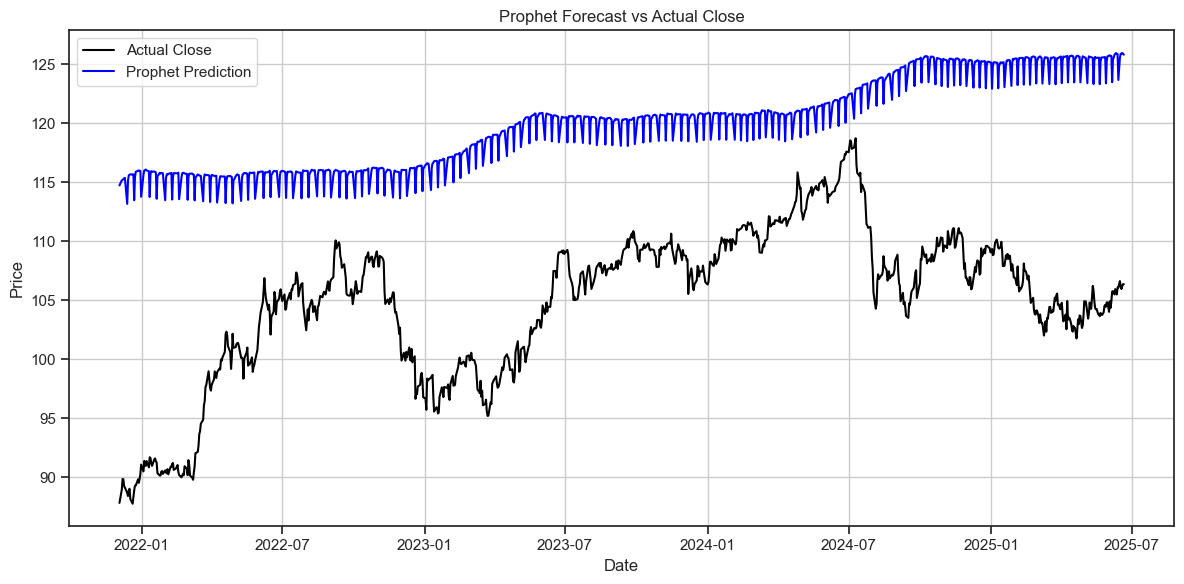

In [73]:
# === Plot Prophet Forecast vs Actual Close Prices ===

plt.figure(figsize=(12, 6))

# Plot actual close prices
plt.plot(prophet_df['Date'], prophet_df['Actual_Close'], label='Actual Close', color='black')

# Plot predicted close prices from Prophet
plt.plot(prophet_df['Date'], prophet_df['Prophet_Predicted'], label='Prophet Prediction', color='blue')

plt.title('Prophet Forecast vs Actual Close')  # Chart title
plt.xlabel('Date')                             # X-axis label
plt.ylabel('Price')                            # Y-axis label
plt.legend()                                   # Display legend
plt.grid(True)                                 # Add grid for readability
plt.tight_layout()                             # Optimize layout
plt.show()                                     # Render the plot

In [74]:
evaluate_model("Prophet", actual, prophet_preds)

Prophet Evaluation:
MAE:  15.0917
RMSE: 16.0360
R²:   -5.6878



In [75]:
# ARIMA

In [76]:
# === ARIMA Forecasting ===
from pmdarima import auto_arima

# === Prepare target and exogenous ===
y_arima_train = df_train['Close'].iloc[:-len(X_test)]
X_arima_train = X_train
X_arima_test = X_test
test_dates = df_train['Date'].iloc[-len(X_arima_test):].values

In [77]:
arima_model = auto_arima(
    y=y_arima_train,
    exogenous=X_arima_train,
    start_p=1, start_q=1,
    max_p=5, max_q=5,
    seasonal=False,
    d=0,  # no differencing, predict actual values
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

In [78]:
# Forecast Close using test exogenous features
arima_preds = arima_model.predict(n_periods=len(X_arima_test), exogenous=X_arima_test)
actual_close = df_train['Close'].iloc[-len(X_arima_test):].values

# Create a DataFrame to compare ARIMA predictions with actual close prices for the test period
arima_plot_df = pd.DataFrame({
    'Date': test_dates, # Corresponding dates
    'Actual_Close': actual_close, # Actual close prices
    'ARIMA_Predicted': arima_preds # Predicted close prices from ARIMA
})

In [79]:
evaluate_model("ARIMA (Auto)", actual_close, arima_preds)

ARIMA (Auto) Evaluation:
MAE:  16.0999
RMSE: 17.1958
R²:   -6.6902



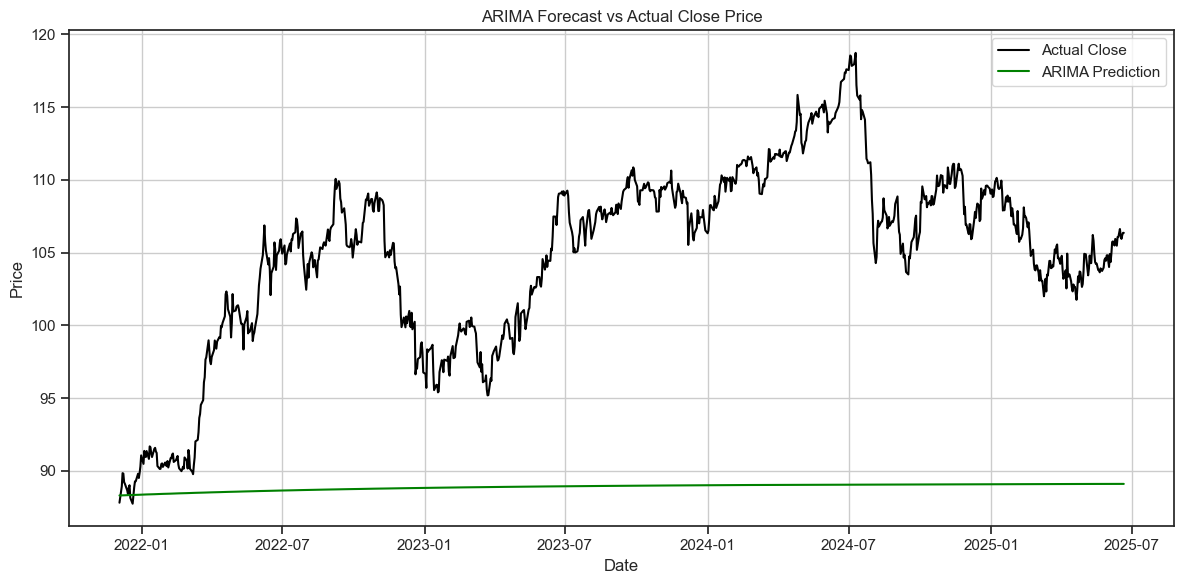

In [80]:
# === Plot ARIMA Forecast vs Actual Close Prices ===

plt.figure(figsize=(12, 6))

# Plot actual close prices
plt.plot(arima_plot_df['Date'], arima_plot_df['Actual_Close'], label='Actual Close', color='black')

# Plot ARIMA predicted close prices
plt.plot(arima_plot_df['Date'], arima_plot_df['ARIMA_Predicted'], label='ARIMA Prediction', color='green')

plt.title('ARIMA Forecast vs Actual Close Price')  # Title of the plot
plt.xlabel('Date')                                 # Label for the x-axis
plt.ylabel('Price')                                # Label for the y-axis
plt.legend()                                       # Show legend to distinguish lines
plt.grid(True)                                     # Add gridlines for better readability
plt.tight_layout()                                 # Adjust layout to fit elements neatly
plt.show()                                         # Display the plot

In [81]:
# LSTM

In [82]:
# === Preprocessing ===
from sklearn.preprocessing import MinMaxScaler  # Scales features to a 0–1 range, improving neural network convergence

# === Keras Model Components ===
from tensorflow.keras.models import Sequential  # Used to build a linear stack of layers for the model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional  
# LSTM: Long Short-Term Memory layer for capturing temporal dependencies
# Dense: Fully connected layer for output or hidden layers
# Dropout: Regularization layer to prevent overfitting by randomly deactivating neurons during training
# Bidirectional: Wraps LSTM to process input in both forward and backward directions

# === Optimizer ===
from tensorflow.keras.optimizers import Adam  # Adaptive optimizer used for updating network weights efficiently

# === Callback ===
from tensorflow.keras.callbacks import EarlyStopping  
# Stops training early if the validation performance stops improving, to avoid overfitting

In [83]:
def reshape_for_lstm(X, y, timesteps=10):
    """
    Transforms feature matrix X and target y into a 3D shape suitable for LSTM input.
    
    Parameters:
        X (array-like): Feature data of shape (samples, features)
        y (array-like): Target values aligned with X
        timesteps (int): Number of past time steps to include for each input sample
    
    Returns:
        X_lstm (np.array): 3D array shaped (samples - timesteps, timesteps, features)
        y_lstm (np.array): Target values corresponding to each X_lstm window
    """
    X_lstm, y_lstm = [], []
    y = np.array(y)  # Ensure y is a NumPy array
    
    # Loop over the data starting from the 'timesteps'-th row
    for i in range(timesteps, len(X)):
        # Take the window of `timesteps` rows as one LSTM input
        X_lstm.append(X[i - timesteps:i])
        # The label is the value right after the window
        y_lstm.append(y[i])
    
    return np.array(X_lstm), np.array(y_lstm)

In [84]:
# === Feature Normalization ===
scaler = MinMaxScaler()  
# Initialize MinMaxScaler to scale features to the [0, 1] range — this helps neural networks converge faster

X_train_scaled = scaler.fit_transform(X_train)  
# Fit the scaler on the training data and transform it — important to avoid data leakage

X_test_scaled = scaler.transform(X_test)  
# Apply the same transformation to the test data using the scaler fitted on training data

In [85]:
# === Reshape Scaled Data for LSTM ===
# Converts the 2D feature arrays into 3D format expected by LSTM:
# (samples, timesteps, features)

X_lstm_train, y_lstm_train = reshape_for_lstm(X_train_scaled, y_train, timesteps=10)
# Generates LSTM-compatible training inputs and targets using a rolling window of 10 timesteps

X_lstm_test, y_lstm_test = reshape_for_lstm(X_test_scaled, y_test, timesteps=10)
# Generates LSTM-compatible testing inputs and targets using the same window size

In [86]:
# === LSTM Model Architecture ===
model = Sequential()  
# Create a sequential model — layers will be added one by one in order

# Add a Bidirectional LSTM layer with 64 units
# Processes the sequence forward and backward to capture richer temporal patterns
# return_sequences=False means it only returns the final output (not the full sequence)
model.add(Bidirectional(
    LSTM(units=64, return_sequences=False),
    input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])  # (timesteps, features)
))

# Add dropout for regularization — randomly sets 30% of input units to zero during training
model.add(Dropout(0.3))

# Add a fully connected dense layer with 32 neurons and ReLU activation
# Helps in learning non-linear combinations of LSTM outputs
model.add(Dense(32, activation='relu'))

# Output layer with 1 neuron (for regression output, i.e., next predicted price)
model.add(Dense(1))

In [87]:
# === Compile the LSTM Model ===
model.compile(
    optimizer=Adam(learning_rate=0.01),  # Use Adam optimizer with a learning rate of 0.01
    loss='mse'  # Use Mean Squared Error loss — suitable for regression tasks
)

# === Set Up Early Stopping ===
early_stop = EarlyStopping(
    monitor='loss',           # Monitor training loss (can be 'val_loss' if using validation data)
    patience=6,               # Stop training if no improvement for 6 consecutive epochs
    restore_best_weights=True  # Revert to the best model weights once stopped
)

# === Train the Model ===
model.fit(
    X_lstm_train, y_lstm_train,      # Training features and targets
    epochs=60,                       # Max number of training epochs
    batch_size=64,                   # Number of samples per batch
    verbose=1,                       # Show progress output
    callbacks=[early_stop]          # Apply early stopping during training
)

# === Make Predictions on Test Data ===
lstm_preds = model.predict(X_lstm_test).flatten()  
# Predict the target values and flatten the output to a 1D array for easier use

Epoch 1/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 2710.0398
Epoch 2/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 126.5452
Epoch 3/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 122.4960
Epoch 4/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 114.1321
Epoch 5/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 98.4396
Epoch 6/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 87.2379
Epoch 7/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 79.6401
Epoch 8/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 78.1663
Epoch 9/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 68.0513
Epoch 10/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 65.2754
Epoch 11/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 63.4758
Epoch 12/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 53.1292
Epoch 13/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 47.0563
Epoch 14/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 41.5739
Epoch 15/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step 

In [88]:
evaluate_model("LSTM", y_lstm_test, lstm_preds)

LSTM Evaluation:
MAE:  1.9866
RMSE: 2.2409
R²:   0.8599



In [89]:
# === Prepare DataFrame for Visualization ===
lstm_plot_df = pd.DataFrame({
    'Date': df_train['Date'].iloc[-len(y_lstm_test):].values,  
    # Extract the corresponding dates for the test set — same length as y_lstm_test
    # Taken from the end of the training set to match reshaped test sequences

    'Actual_Close': y_lstm_test,     # True target values from the test set
    'LSTM_Predicted': lstm_preds     # Predicted values from the trained LSTM model
})

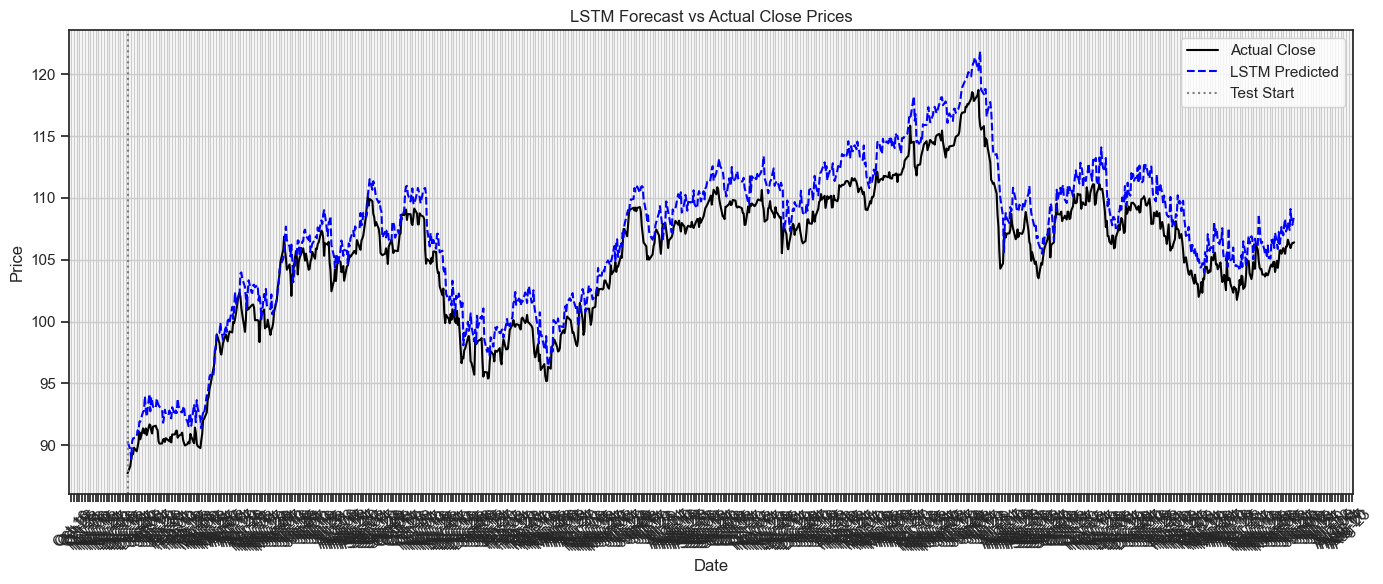

In [90]:
# Plot actual vs. predicted
plt.figure(figsize=(14, 6))
plt.plot(lstm_plot_df['Date'], lstm_plot_df['Actual_Close'], label='Actual Close', color='black')
plt.plot(lstm_plot_df['Date'], lstm_plot_df['LSTM_Predicted'], label='LSTM Predicted', color='blue', linestyle='--')

plt.axvline(x=lstm_plot_df['Date'].iloc[0], color='gray', linestyle=':', label='Test Start')

# Format x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)

plt.title("LSTM Forecast vs Actual Close Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [91]:
# XGBOOST

In [92]:
# === XGBoost Regression Setup ===

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
# TimeSeriesSplit: ensures time-aware cross-validation (no data leakage from future to past)
# RandomizedSearchCV: performs randomized hyperparameter search over specified distributions

from scipy.stats import uniform, randint
# Used to define probabilistic distributions for random search of hyperparameters

from xgboost import XGBRegressor
# XGBoost regression model — efficient and powerful for structured/tabular data

# === Time-aware Cross-Validation ===
tscv = TimeSeriesSplit(n_splits=5)
# Splits data into 5 consecutive folds while preserving temporal order (no shuffling)

# === Hyperparameter Distributions for Random Search ===
param_dist = {
    'n_estimators': randint(50, 300),             # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.2),          # Step size shrinkage
    'max_depth': randint(3, 10),                  # Maximum tree depth
    'min_child_weight': randint(1, 6),            # Minimum sum of instance weight (hessian) in a child
    'gamma': uniform(0, 0.5),                     # Minimum loss reduction required to make a further split
    'subsample': uniform(0.7, 0.3),               # Subsample ratio of the training instances
    'colsample_bytree': uniform(0.7, 0.3)         # Subsample ratio of columns for each tree
}

In [ ]:
# === Initialize Base XGBoost Regressor ===
xgb = XGBRegressor(objective='reg:squarederror')
# Uses squared error as the loss function — suitable for regression tasks

# === Set Up Randomized Hyperparameter Search ===
random_search = RandomizedSearchCV(
    estimator=xgb,                   # Base model to tune
    param_distributions=param_dist,  # Dictionary of hyperparameter distributions (defined earlier)
    n_iter=20,                       # Number of random combinations to try (more = better, slower)
    cv=tscv,                         # Use time series cross-validation
    verbose=1,                       # Output progress during training
    n_jobs=-1,                       # Use all available CPU cores for parallel training
    scoring='neg_root_mean_squared_error',  # RMSE as the scoring metric (negated for compatibility)
    random_state=42                  # Ensures reproducible results
)

# === Perform Hyperparameter Tuning ===
random_search.fit(X_train, y_train)
# Searches for the best hyperparameters using randomized sampling and cross-validation

# === Retrieve the Best Trained XGBoost Model ===
best_xgb = random_search.best_estimator_

# === Make Predictions on Test Data ===
xgb_preds = best_xgb.predict(X_test)
# Predicts target values using the best model found during tuning

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
# === Combine Actual and Model Predictions into a Single DataFrame ===
compare_df = pd.DataFrame({
    'Date': df_train['Date'].iloc[-len(y_lstm_test):].values,
    # Extracts dates aligned with LSTM test window (since reshaping skips initial rows)

    'Actual_Close': y_lstm_test,  
    # True target values from the test set

    'LSTM_Predicted': lstm_preds,  
    # Predicted values from the LSTM model

    'XGBoost_Predicted': xgb_preds[-len(y_lstm_test):]  
    # Selects the last n values from XGBoost predictions to match the LSTM prediction window
})

In [ ]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(compare_df['Date'], compare_df['Actual_Close'], label='Actual Close', color='black')
plt.plot(compare_df['Date'], compare_df['LSTM_Predicted'], label='LSTM Prediction', color='blue', linestyle='--')
plt.plot(compare_df['Date'], compare_df['XGBoost_Predicted'], label='XGBoost Prediction', color='green', linestyle='-.')

plt.axvline(x=compare_df['Date'].iloc[0], color='gray', linestyle=':', label='Test Start')

# X-axis formatting
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)

plt.title("Actual vs LSTM vs XGBoost Predictions")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Ensure all prediction arrays from Prophet, ARIMA, and XGBoost have the same length for proper comparison
assert len(prophet_preds) == len(xgb_preds)

In [ ]:
# Ensemble models

In [ ]:
# === Average Ensemble Prediction ===
# Combine forecasts from Prophet, LSTM, and XGBoost using simple averaging

# Determine how many predictions to include — use LSTM length (shortest due to windowing)
forecast_len = len(lstm_preds)

# Trim Prophet and XGBoost predictions to match LSTM's forecast range
trimmed_prophet = prophet_preds[-forecast_len:]     # Keep last `forecast_len` Prophet predictions
trimmed_xgb = xgb_preds[-forecast_len:]             # Keep last `forecast_len` XGBoost predictions

# Compute the average of the three model outputs for each time point
ensemble_preds = (trimmed_prophet + lstm_preds + trimmed_xgb) / 3
# This produces a balanced ensemble forecast that blends strengths of all three models

In [ ]:
# === Weighted Ensemble Prediction ===

# Step 1: Determine the shortest prediction length to align all model outputs
min_len = min(len(prophet_preds), len(lstm_preds), len(xgb_preds))

# Step 2: Trim all predictions and ground truth to the same length from the end
prophet_trimmed = prophet_preds[-min_len:]   # Latest Prophet predictions
lstm_trimmed = lstm_preds[-min_len:]         # Latest LSTM predictions
xgb_trimmed = xgb_preds[-min_len:]           # Latest XGBoost predictions
y_test_trimmed = y_test[-min_len:]           # Corresponding true target values

# Step 3: Compute a weighted average of model predictions
# Assign heavier weight (80%) to XGBoost, and lighter weight (10% each) to Prophet and LSTM
weighted_preds = (
    0.1 * prophet_trimmed +
    0.1 * lstm_trimmed +
    0.8 * xgb_trimmed
)

# Step 4: Evaluate the weighted ensemble against the actual target values
evaluate_model("Weighted Ensemble", y_test_trimmed, weighted_preds)
# This function (assumed defined earlier) prints performance metrics like RMSE, MAE, etc.

In [ ]:
# === Create Ensemble Comparison DataFrame ===

# Construct a DataFrame to compare actual close prices with all model predictions
# Align everything to min_len
ensemble_df = pd.DataFrame({
    'Date': df_train['Date'].iloc[-min_len:].values,
    'Actual_Close': df_train['Close'].iloc[-min_len:].values,
    'Prophet': prophet_preds[-min_len:],
    'ARIMA': arima_preds[-min_len:],
    'LSTM': lstm_preds[-min_len:],
    'XGBoost': xgb_preds[-min_len:],
    'Ensemble': ensemble_preds[-min_len:],
    'Weighted Ensemble': weighted_preds[-min_len:]
})


In [ ]:
# === Plot Forecast Comparison ===

plt.figure(figsize=(14, 7))

# Plot actual close prices
plt.plot(ensemble_df['Date'], ensemble_df['Actual_Close'], label='Actual Close', color='black', linewidth=2)

# Plot individual model predictions
plt.plot(ensemble_df['Date'], ensemble_df['Prophet'], label='Prophet', linestyle='--', alpha=0.7)
plt.plot(ensemble_df['Date'], ensemble_df['ARIMA'], label='ARIMA', linestyle='--', alpha=0.7)
plt.plot(ensemble_df['Date'], ensemble_df['XGBoost'], label='XGBoost', linestyle='--', alpha=0.7)
plt.plot(ensemble_df['Date'], ensemble_df['LSTM'], label='LSTM', linestyle='--', alpha=0.7)

# Plot ensemble predictions
plt.plot(ensemble_df['Date'], ensemble_df['Ensemble'], label='Ensemble', color='blue', linewidth=2)
plt.plot(ensemble_df['Date'], ensemble_df['Weighted Ensemble'], label='Weighted Ensemble', linestyle='-', color='green')

# Final plot formatting
plt.title('Forecast Comparison: Prophet vs ARIMA vs LSTM vs XGBoost vs Ensemble')  # Title
plt.xlabel('Date')     # X-axis label
plt.ylabel('Price')    # Y-axis label
plt.legend()           # Legend to identify lines
plt.grid(True)         # Add gridlines
plt.tight_layout()     # Adjust layout for clarity
plt.show()             # Display the plot

In [ ]:
# Metrics evaluation

In [ ]:
# Import regression evaluation metrics from scikit-learn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# === Evaluate All Models ===

# Now safely evaluate models
evaluate_model("Prophet", y_test_trimmed, prophet_preds[-min_len:])
evaluate_model("ARIMA", y_test_trimmed, arima_preds[-min_len:])
evaluate_model("XGBoost", y_test_trimmed, xgb_preds[-min_len:])
evaluate_model("LSTM", y_test_trimmed, lstm_preds[-min_len:])
evaluate_model("Ensemble", y_test_trimmed, ensemble_preds[-min_len:])
evaluate_model("Weighted Ensemble", y_test_trimmed, weighted_preds[-min_len:])


In [ ]:
# Stacking Ensembling

In [ ]:
# === Prepare Data for Stacking (Level 0) ===

# Trim all to match min_len
stack_X_train = np.vstack([
    prophet_preds[-min_len:],    # Column 1: Prophet
    arima_preds[-min_len:],      # Column 2: ARIMA
    xgb_preds[-min_len:],        # Column 3: XGBoost
    lstm_preds[-min_len:]        # Column 4: LSTM
]).T  # Transpose to (n_samples, n_models)

# Align the target values
stack_y_train = y_test_trimmed.values

In [ ]:
# Initialize dictionary to store evaluation metrics
meta_model_scores = {}

In [ ]:
# === LassoCV Meta-Model ===
from sklearn.linear_model import LassoCV

# Initialize and train Lasso with cross-validated alpha
lasso_meta = LassoCV(alphas=np.logspace(-4, 1, 50), cv=5)
lasso_meta.fit(stack_X_train, stack_y_train)

# Generate predictions
lasso_preds = lasso_meta.predict(stack_X_train)
trimmed_y_test = y_test[-len(lasso_preds):].values

# Evaluate and display performance
evaluate_model("LassoCV Meta", trimmed_y_test, lasso_preds)

# Store metrics in dictionary
meta_model_scores['LassoCV'] = {
    'RMSE': np.sqrt(mean_squared_error(trimmed_y_test, lasso_preds)),
    'MAE': mean_absolute_error(trimmed_y_test, lasso_preds),
    'R2': r2_score(trimmed_y_test, lasso_preds)
}

In [ ]:
assert len(y_test_trimmed) == len(trimmed_y_test)

In [ ]:
# === Random Forest Meta-Model ===
from sklearn.ensemble import RandomForestRegressor

# Initialize and train Random Forest
rf_meta = RandomForestRegressor(n_estimators=100, random_state=42)
rf_meta.fit(stack_X_train, stack_y_train)

# Generate predictions
rf_preds = rf_meta.predict(stack_X_train)

# Evaluate and display performance
evaluate_model("Random Forest Meta", trimmed_y_test, rf_preds)

# Store metrics in dictionary
meta_model_scores['RandomForest'] = {
    'RMSE': np.sqrt(mean_squared_error(trimmed_y_test, rf_preds)),
    'MAE': mean_absolute_error(trimmed_y_test, rf_preds),
    'R2': r2_score(trimmed_y_test, rf_preds)
}

In [ ]:
# === Gradient Boosting Meta-Model ===
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train Gradient Boosting Regressor
gb_meta = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05)
gb_meta.fit(stack_X_train, stack_y_train)

# Generate predictions
gb_preds = gb_meta.predict(stack_X_train)

# Evaluate and display performance
evaluate_model("Gradient Boosting Meta", trimmed_y_test, gb_preds)

# Store metrics in dictionary
meta_model_scores['GradientBoosting'] = {
    'RMSE': np.sqrt(mean_squared_error(trimmed_y_test, gb_preds)),
    'MAE': mean_absolute_error(trimmed_y_test, gb_preds),
    'R2': r2_score(trimmed_y_test, gb_preds)
}

In [ ]:
# === Ridge Regression as Meta-Model ===

from sklearn.linear_model import RidgeCV

# Initialize RidgeCV with cross-validation over a range of alpha values
ridge_meta = RidgeCV(alphas=np.logspace(-3, 2, 10), cv=5)

# Fit the model using Level 0 predictions (stacked inputs)
ridge_meta.fit(stack_X_train, stack_y_train)

# Predict using the trained Ridge meta-model
ridge_preds = ridge_meta.predict(stack_X_train)

# Evaluate the RidgeCV meta-model's performance
evaluate_model("RidgeCV Meta", trimmed_y_test, ridge_preds)

meta_model_scores['RidgeCV'] = {
    'RMSE': np.sqrt(mean_squared_error(trimmed_y_test, gb_preds)),
    'MAE': mean_absolute_error(trimmed_y_test, gb_preds),
    'R2': r2_score(trimmed_y_test, gb_preds)
}

In [ ]:
# === Use Best Meta-Model from Dictionary ===

# Find the model name with the lowest RMSE
best_model_name = min(meta_model_scores, key=lambda k: meta_model_scores[k]['RMSE'])

print(f" Best Meta-Model based on RMSE: {best_model_name}")

# Initialize and fit the best model
if best_model_name == 'RidgeCV':
    from sklearn.linear_model import RidgeCV
    meta_model = RidgeCV(alphas=np.logspace(-3, 2, 10), cv=5)
elif best_model_name == 'LassoCV':
    from sklearn.linear_model import LassoCV
    meta_model = LassoCV(alphas=np.logspace(-4, 1, 50), cv=5)
elif best_model_name == 'RandomForest':
    from sklearn.ensemble import RandomForestRegressor
    meta_model = RandomForestRegressor(n_estimators=100, random_state=42)
elif best_model_name == 'GradientBoosting':
    from sklearn.ensemble import GradientBoostingRegressor
    meta_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05)
else:
    raise ValueError(f"Unknown model: {best_model_name}")

# Fit the best meta-model
meta_model.fit(stack_X_train, stack_y_train)

# Generate final stacked predictions
stacked_preds = meta_model.predict(stack_X_train)


In [ ]:
# Evaluate the performance of the stacked ensemble model against actual test values
evaluate_model("Stacked Ensemble", trimmed_y_test, stacked_preds)

In [ ]:
# === Plot: Weighted vs Stacked Ensemble ===

# Add stacked ensemble predictions to the comparison DataFrame
ensemble_df['Stacked Ensemble'] = stacked_preds

plt.figure(figsize=(15, 7))

# Plot actual close prices
plt.plot(ensemble_df['Date'], ensemble_df['Actual_Close'], label='Actual Close', color='black', linewidth=2)

# Plot weighted ensemble predictions
plt.plot(ensemble_df['Date'], ensemble_df['Weighted Ensemble'], label='Weighted', linestyle='--', color='green')

# Plot stacked ensemble predictions
plt.plot(ensemble_df['Date'], ensemble_df['Stacked Ensemble'], label='Stacked Ensemble', color='purple', linewidth=2)

# Final plot formatting
plt.title('Ensemble Comparison: Weighted vs Stacked')  # Chart title
plt.xlabel('Date')                                     # X-axis label
plt.ylabel('Price')                                    # Y-axis label
plt.legend()                                           # Display legend
plt.grid(True)                                         # Add grid
plt.tight_layout()                                     # Adjust layout
plt.show()                                             # Display the plot

In [ ]:
# CROSS VAL FOR META AND CHECK FOR OVERFITTING

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# === Cross-Validation Scoring for Random Forest Meta-Model ===

# Use negative scoring because scikit-learn expects "higher is better"
cv_rmse = -cross_val_score(rf_meta, stack_X_train, stack_y_train, cv=cv, scoring='neg_root_mean_squared_error')
# Compute RMSE across all CV folds

cv_mae = -cross_val_score(rf_meta, stack_X_train, stack_y_train, cv=cv, scoring='neg_mean_absolute_error')
# Compute MAE across all CV folds

cv_r2 = cross_val_score(rf_meta, stack_X_train, stack_y_train, cv=cv, scoring='r2')
# Compute R² (explained variance) — higher is better

# === Train Meta-Model on Full Training Stack ===
rf_meta.fit(stack_X_train, stack_y_train)
# Fit the Random Forest meta-model using all training data

rf_preds = rf_meta.predict(stack_X_train)
# Predict training targets using the trained meta-model — for comparison with true values

# === Output Cross-Validation Results ===
print("📊 Random Forest Meta Cross-Validation:")
print(f"  ▸ CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"  ▸ CV MAE : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}")
print(f"  ▸ CV R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print()

# === Final Evaluation on Hold-Out Data ===
evaluate_model("Random Forest Meta (Hold-out)", trimmed_y_test, rf_preds)
# Compare predictions from the meta-model to true targets in a separate hold-out set

# === Log Cross-Validation Metrics for Later Use or Reporting ===
meta_model_scores['RandomForest_CV'] = {
    'CV_RMSE': cv_rmse.mean(),
    'CV_MAE': cv_mae.mean(),
    'CV_R2': cv_r2.mean()
}

In [ ]:
# === Train Random Forest Meta-Model ===
rf_meta.fit(X_train, y_train)
# Fit the meta-model using training features and targets

# === Make Predictions on Training and Testing Data ===
y_train_pred = rf_meta.predict(X_train)  # Predict on training set
y_test_pred = rf_meta.predict(X_test)    # Predict on test set

# === Trim Predictions and Targets to Match Shortest Length (min_len) ===
# Ensures fair comparison when evaluating models that operate on different sequence lengths
y_train_trim = y_train[-min_len:]
y_train_pred_trim = y_train_pred[-min_len:]
y_test_trim = y_test[-min_len:]
y_test_pred_trim = y_test_pred[-min_len:]

# === Evaluate Train Performance ===
print("📊 Train Performance (Trimmed):")
evaluate_model("Meta Model Train Data", y_train, y_train_pred)
# Assesses how well the model fits the training data

# === Evaluate Test Performance ===
print("\n📊 Test Performance (Trimmed):")
evaluate_model("Meta Model Test Data", y_test, y_test_pred)
# Evaluates generalization to unseen test data

In [ ]:
# === Calculate Prediction Gaps (Residuals) ===

predicted = y_test_pred   # Model predictions on test data
expected = y_test         # Actual values from test set
gap = []                  # List to store residuals

# Loop through predictions and actual values
for p, e in zip(predicted, expected):
    # Compute the difference (residual) between expected and predicted values
    # This shows how far off each prediction was from the true value
    gap.append(e - float(p))  # Cast p to float in case it's a NumPy type

In [ ]:
# === Analyze Residual Extremes ===

print(max(gap))  
# Prints the largest positive residual (biggest underprediction)

print(abs(min(gap)))  
# Prints the absolute value of the largest negative residual (biggest overprediction)

In [ ]:
import os
import joblib

# Ensure models directory exists
os.makedirs("models", exist_ok=True)
joblib.dump(df, "models/original_df.pkl")


# === Base Models ===
# XGBoost
best_xgb.save_model("models/xgb_model.json")

# ARIMA
joblib.dump(arima_model, "models/arima_model.pkl")

# Prophet
joblib.dump(prophet, "models/prophet_model.pkl")

# === Meta-Models ===
joblib.dump(meta_model, "models/meta_model_ridge.pkl")
joblib.dump(lasso_meta, "models/meta_model_lasso.pkl")
joblib.dump(rf_meta, "models/meta_model_rf.pkl")
joblib.dump(gb_meta, "models/meta_model_gb.pkl")

# === Ensemble Results ===
joblib.dump(ensemble_df, "models/ensemble_results_df.pkl")

# Optional: Save feature sets
joblib.dump((X_train, X_test, y_train, y_test), "models/data_split.pkl")

In [ ]:
# Predicting Future Outcome

In [ ]:
# === Prepare Latest 2 Weeks Data for Prediction ===
df_last_2weeks_x = df_last_2weeks.drop(columns=['Date', 'target_regression', 'target_classification'])
# Drop non-feature columns (date and targets) to get feature matrix for prediction

vv = 'target_regression'  # Specify which target variable to evaluate

In [ ]:
df_last_2weeks.shape

In [ ]:
# === Make Predictions on the Last 2 Weeks ===
predicted = rf_meta.predict(df_last_2weeks_x)     # Predict using trained meta-model
expected = df_last_2weeks[vv].values              # Get actual values of the regression target

# === Display and Store Gaps Between Expected and Predicted ===
gap = []
for p, e in zip(predicted, expected):
    print(f'predicted: {p:.5f}, expected: {e}')   # Print each prediction vs. actual
    gap.append(e - float(p))  

In [ ]:
# === Calculate Evaluation Metrics ===
mae = mean_absolute_error(df_last_2weeks['Close'], predicted)
# MAE: average of the absolute differences between actual and predicted values

rmse = np.sqrt(mean_squared_error(df_last_2weeks['Close'], predicted))
# RMSE: square root of average squared error — penalizes larger errors more than MAE

r2 = r2_score(df_last_2weeks['Close'], predicted)
# R²: proportion of variance explained by the model (1.0 = perfect, 0 = baseline)

# === Plot Actual vs Predicted Prices ===
plt.figure(figsize=(15, 7))  # Set canvas size

# Plot actual closing prices
plt.plot(df_last_2weeks['Date'], df_last_2weeks['Close'],
         label='Actual Close', color='black', linewidth=2)

# Plot model predictions
plt.plot(df_last_2weeks['Date'], predicted,
         label='Predicted Close', color='blue', linewidth=2)

# === Annotate the Chart with Evaluation Scores ===
plt.text(
    0.01, 0.95,
    f'MAE:  {mae:.6f}\nRMSE: {rmse:.6f}\nR²:   {r2:.4f}',
    transform=plt.gca().transAxes,  # Position relative to axes
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="black")  # Style the box
)

# === Final Chart Styling ===
plt.title('📈 Comparison: Actual vs Predicted Close (Last 2 Weeks)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)  # Improve date readability
plt.show()  # Display the plot

In [ ]:
# === Compute Residuals ===
gap = [e - float(p) for p, e in zip(predicted, expected)]
# Difference between actual and predicted values (expected - predicted)

# === Define X-Axis Labels ===
labels = df_last_2weeks['Date'][-len(gap):] if 'Date' in df_last_2weeks.columns else range(len(gap))
# Use actual dates from the DataFrame for x-axis if available, otherwise fallback to index

# === Plot Residuals as a Bar Chart ===
plt.figure(figsize=(12, 5))  # Set figure size

bars = plt.bar(labels, gap, color='crimson', alpha=0.6)
# Plot each residual as a bar — red bars for visual emphasis

plt.axhline(0, color='black', linestyle='--')
# Add horizontal line at 0 to distinguish over- and under-predictions

# === Styling and Labels ===
plt.title("Prediction Residuals (Expected - Predicted)")
plt.xlabel("Date" if isinstance(labels[0], (str, pd.Timestamp)) else "Sample Index")
plt.ylabel("Error (Gap)")
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis ticks for better readability
plt.tight_layout()
plt.show()  # Display the plot

In [ ]:
# FORECAST

In [ ]:
# === Clone Full Historical Data ===
history = df.sort_values("Date").copy().reset_index(drop=True)
# Make a sorted, clean copy of the dataset to simulate live feature updates without altering the original

# === Storage for Future Predictions ===
future_preds = []
# Initialize an empty list to collect predictions over simulated steps

# === Feature Engineering Function for Recursive Predictions ===
def compute_features(df):
    # --- Time-Based Features ---
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['is_week_start'] = (df['dayofweek'] == 0).astype(int)
    df['is_week_end'] = (df['dayofweek'] == 4).astype(int)

    # --- Return Features ---
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    df['return_1d'] = df['Close'].pct_change()
    df['log_return_positive'] = (df['Log_Return'] > 0).astype(int)

    # --- Lag Features ---
    df['lag_1'] = df['Close'].shift(1)
    df['lag_2'] = df['Close'].shift(2)
    df['lag_3'] = df['Close'].shift(3)

    # --- Simple Moving Averages (SMAs) ---
    df['Sma_5'] = df['Close'].rolling(window=5).mean()
    df['Sma_21'] = df['Close'].rolling(window=21).mean()
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['SMA_100'] = df['Close'].rolling(window=100).mean()

    # --- Volatility Metrics ---
    df['volatility_10'] = df['Log_Return'].rolling(window=10).std()
    df['volatility_21'] = df['Log_Return'].rolling(window=21).std()

    # --- RSI Calculation ---
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # --- MACD & Signal ---
    ema_fast = df['Close'].ewm(span=12, adjust=False).mean()
    ema_slow = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_fast - ema_slow
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_diff'] = df['MACD'] - df['MACD_signal']

    # --- Bollinger Bands ---
    sma_20 = df['Close'].rolling(window=20).mean()
    std_20 = df['Close'].rolling(window=20).std()
    df['BB_upper'] = sma_20 + 2 * std_20
    df['BB_lower'] = sma_20 - 2 * std_20
    df['BB_width'] = df['BB_upper'] - df['BB_lower']

    # --- Average True Range (ATR) ---
    df['H-L'] = df['High'] - df['Low']
    df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
    df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)
    df['ATR'] = df['TR'].rolling(window=14).mean()

    # --- Momentum and Rate of Change ---
    df['momentum_3'] = df['Close'] - df['Close'].shift(3)
    df['momentum_7'] = df['Close'] - df['Close'].shift(7)
    df['roc_3'] = df['Close'].pct_change(periods=3)
    df['roc_7'] = df['Close'].pct_change(periods=7)

    # --- Short-Term Volatility Windows ---
    df['vol_5'] = df['Close'].rolling(window=5).std()
    df['vol_10'] = df['Close'].rolling(window=10).std()

    # --- Slope of 5-Day SMA ---
    df['sma_5_slope'] = df['sma_5'].diff()

    # --- Candle Pattern Features ---
    df['upper_shadow'] = df['High'] - df[['Open', 'Close']].max(axis=1)
    df['lower_shadow'] = df[['Open', 'Close']].min(axis=1) - df['Low']
    df['body'] = abs(df['Close'] - df['Open'])
    df['range'] = df['High'] - df['Low']

    df['is_doji'] = (df['body'] / df['range'] < 0.1).astype(int)
    df['is_hammer'] = ((df['lower_shadow'] > 2 * df['body']) & (df['upper_shadow'] < df['body'])).astype(int)
    df['is_inverted_hammer'] = ((df['upper_shadow'] > 2 * df['body']) & (df['lower_shadow'] < df['body'])).astype(int)

    df['is_bullish_engulfing'] = (
        (df['Close'].shift(1) < df['Open'].shift(1)) &
        (df['Close'] > df['Open']) &
        (df['Open'] < df['Close'].shift(1)) &
        (df['Close'] > df['Open'].shift(1))
    ).astype(int)

    df['is_bearish_engulfing'] = (
        (df['Close'].shift(1) > df['Open'].shift(1)) &
        (df['Close'] < df['Open']) &
        (df['Open'] > df['Close'].shift(1)) &
        (df['Close'] < df['Open'].shift(1))
    ).astype(int)

    # --- Binary Technical Signals ---
    df['price_above_sma20'] = (df['Close'] > df['SMA_20']).astype(int)
    df['price_above_sma50'] = (df['Close'] > df['SMA_50']).astype(int)
    df['sma_crossover'] = (df['sma_5'] > df['sma_10']).astype(int)

    return df

In [ ]:
# === Relative Strength Index (RSI) Calculator ===
def compute_rsi(series, period=14):
    delta = series.diff()  # Calculate daily price change

    gain = delta.clip(lower=0)  # Keep only positive gains (up days)
    loss = -delta.clip(upper=0)  # Keep only losses as positive numbers (down days)

    avg_gain = gain.rolling(window=period).mean()  # Rolling average of gains over the period
    avg_loss = loss.rolling(window=period).mean()  # Rolling average of losses over the period

    rs = avg_gain / avg_loss  # Relative Strength

    return 100 - (100 / (1 + rs))  # RSI formula: scaled to range from 0 to 100

In [ ]:
# === Moving Average Convergence Divergence (MACD) Calculator ===
def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    # Compute fast EMA (typically 12-period)

    ema_slow = series.ewm(span=slow, adjust=False).mean()
    # Compute slow EMA (typically 26-period)

    macd = ema_fast - ema_slow
    # MACD Line: Difference between fast and slow EMAs

    signal_line = macd.ewm(span=signal, adjust=False).mean()
    # Signal Line: EMA of MACD (typically 9-period)

    return macd, signal_line, macd - signal_line
    # Returns:
    # ▸ MACD line
    # ▸ Signal line
    # ▸ MACD histogram (difference between MACD and signal)

In [ ]:
# === Bollinger Bands Calculator ===
def compute_bbands(series, period=20, num_std=2):
    sma = series.rolling(window=period).mean()
    # Simple Moving Average (center line)

    std = series.rolling(window=period).std()
    # Rolling standard deviation over the same window

    upper = sma + num_std * std
    # Upper Band: SMA + (num_std × STD)

    lower = sma - num_std * std
    # Lower Band: SMA - (num_std × STD)

    width = upper - lower
    # Band Width: Measures market volatility

    return upper, lower, width
    # Returns:
    # ▸ Upper Band
    # ▸ Lower Band
    # ▸ Band Width

In [ ]:
import numpy as np

# === Step 1: Initialize Forecast Context ===
history = df.sort_values("Date").copy().reset_index(drop=True)
# Make a clean, sorted copy of historical data to simulate forward updates
future_preds = []  # Store forecast results

# === Step 2: Walk Forward Over Next 7 Days ===
for i in range(7):
    next_date = history.iloc[-1]['Date'] + pd.Timedelta(days=1)  # Forecast date
    last_row = history.iloc[-1]  # Most recent row for reference

    # Estimate market volatility using ATR (or fallback to 1% of last close)
    atr = history.iloc[-2].get('ATR', np.nan)
    if pd.isna(atr):
        atr = last_row['Close'] * 0.01
    high_noise = np.random.uniform(0.3, 1.0) * atr
    low_noise = np.random.uniform(0.3, 1.0) * atr

    # === Step 3: Create Simulated Row for Next Day ===
    new_row = {
        'Date': next_date,
        'Open': last_row['Close'],  # Opening price = previous close
        'Close': np.nan,            # Placeholder — will be updated by model
        'High': last_row['Close'] + high_noise,
        'Low': last_row['Close'] - low_noise,
        'Volume': last_row['Volume'],  # Hold volume constant (can be randomized later)
    }

    # === Step 4: Append and Recompute Features ===
    history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

    # Recalculate indicators using only the tail for efficiency
    tail_window = 100
    tail = compute_features(history.tail(tail_window).copy())

    tail.fillna(method='ffill', inplace=True)  # Forward-fill for stability
    tail.fillna(0, inplace=True)               # Backfill any remaining nulls

    # Inject updated feature values into full history
    history.update(tail)

    # === Step 5: Make Prediction for Next Day ===
    X_next = history.iloc[[-1]].reindex(columns=features.columns, fill_value=0)
    y_next = rf_meta.predict(X_next)[0]  # Predict next closing price
    history.at[history.index[-1], 'Close'] = y_next  # Assign prediction to Close

    # Store forecast
    future_preds.append((next_date, y_next))

# === Step 6: Output Predictions ===
for date, pred in future_preds:
    print(f"📅 {date.date()} → 🔮 Predicted Close: {pred:.5f}")

In [ ]:
# === Convert Predictions to DataFrame ===
forecast_df = pd.DataFrame(future_preds, columns=["Date", "Predicted_Close"])
# Structure the list of (date, prediction) into a tidy DataFrame

# === Plot the Forecast vs Recent Actuals ===
plt.figure(figsize=(10, 5))  # Canvas size

# Plot the most recent actual 30 days from history
plt.plot(history['Date'][-30:], history['Close'][-30:], label='Recent Actual')

# Overlay forecasted next 7 days
plt.plot(forecast_df['Date'], forecast_df['Predicted_Close'],
         marker='o', linestyle='--', color='red', label='Forecast')

# === Chart Decoration ===
plt.title("📉 7-Day Rolling Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)  # Better date formatting
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()  # Render the chart

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'notebook'  # Set Plotly to display inline

# === Prepare Recent Historical Data ===
recent_data = history[-30:].copy()  # Last 30 days for candlesticks

# Initialize interactive Plotly figure
fig = go.Figure()

# === Candlestick Trace (Actual Prices) ===
fig.add_trace(go.Candlestick(
    x=recent_data['Date'],
    open=recent_data['Open'],
    high=recent_data['High'],
    low=recent_data['Low'],
    close=recent_data['Close'],
    name="Recent Actual"
))

# === Line Forecast (Future Predicted Close) ===
forecast_df = pd.DataFrame(future_preds, columns=["Date", "Predicted_Close"])

fig.add_trace(go.Scatter(
    x=forecast_df["Date"],
    y=forecast_df["Predicted_Close"],
    mode='lines+markers',
    name='7-Day Forecast',
    line=dict(color='orange', dash='dash'),
    marker=dict(size=6),
    hovertemplate='📅 %{x|%Y-%m-%d}<br>🔮 Forecast: %{y:.5f}<extra></extra>'
))

# === Final Layout and Style ===
fig.update_layout(
    title="📉 7-Day Rolling Forecast (Candlestick + Prediction)",
    xaxis_title="Date",
    yaxis_title="Close Price",
    xaxis_rangeslider_visible=False,  # Hide range slider
    hovermode="x unified",  # Shared hover across traces
    template="plotly_white",
    height=500
)

fig.show()

In [ ]:
forecast_df.to_csv("7_day_forecast.csv", index=False)